In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

PROCESSED_DIR = Path("../data/processed")
MODELS_DIR    = Path("../models")
RESULTS_DIR   = Path("../results")
MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU:  {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU:  NVIDIA GeForce GTX 1650
VRAM: 3.9 GB


In [2]:
class LOBDataset(Dataset):
    """
    Sliding window dataset for LOB sequence modeling.
    Each sample: (window of T snapshots, label at final timestep)
    X shape per sample: (T, n_features)
    """
    def __init__(self, X: np.ndarray, y: np.ndarray, window: int = 100):
        self.X      = torch.tensor(X, dtype=torch.float32)
        self.y      = torch.tensor(y, dtype=torch.long)
        self.window = window

    def __len__(self):
        return len(self.X) - self.window

    def __getitem__(self, idx):
        x_seq = self.X[idx : idx + self.window]
        label = self.y[idx + self.window - 1]
        return x_seq, label

print("LOBDataset defined")

LOBDataset defined


In [3]:
with open(PROCESSED_DIR / "lobster_processed.pkl", "rb") as f:
    saved = pickle.load(f)

splits  = saved["splits"]
scalers = saved["scalers"]
config  = saved["config"]
TICKERS = config["tickers"]
WINDOW  = config["window"]

print(f"Config: {config}")
print(f"Tickers: {TICKERS}")
print(f"Splits loaded for: {list(splits.keys())}")

Config: {'k': 50, 'alpha': 1e-05, 'window': 100, 'batch_size': 512, 'tickers': ['AAPL', 'AMZN', 'GOOG']}
Tickers: ['AAPL', 'AMZN', 'GOOG']
Splits loaded for: ['AAPL', 'AMZN', 'GOOG']


In [4]:
BATCH_SIZE = config["batch_size"]

loaders = {}
for ticker in TICKERS:
    train_ds = LOBDataset(*splits[ticker]["train"], window=WINDOW)
    val_ds   = LOBDataset(*splits[ticker]["val"],   window=WINDOW)
    test_ds  = LOBDataset(*splits[ticker]["test"],  window=WINDOW)

    loaders[ticker] = {
        "train": DataLoader(train_ds, batch_size=BATCH_SIZE,
                            shuffle=False, num_workers=0, pin_memory=True),
        "val":   DataLoader(val_ds,   batch_size=BATCH_SIZE,
                            shuffle=False, num_workers=0, pin_memory=True),
        "test":  DataLoader(test_ds,  batch_size=BATCH_SIZE,
                            shuffle=False, num_workers=0, pin_memory=True),
    }

print("Loaders rebuilt:")
for ticker in TICKERS:
    xb, yb = next(iter(loaders[ticker]["train"]))
    print(f"  {ticker}: x={xb.shape}  y={yb.shape}")

Loaders rebuilt:
  AAPL: x=torch.Size([512, 100, 71])  y=torch.Size([512])
  AMZN: x=torch.Size([512, 100, 71])  y=torch.Size([512])
  GOOG: x=torch.Size([512, 100, 71])  y=torch.Size([512])


In [5]:
def compute_class_weights(y_train: np.ndarray, n_classes: int = 3) -> torch.Tensor:
    counts  = np.bincount(y_train, minlength=n_classes).astype(float)
    weights = 1.0 / counts
    weights = weights / weights.sum() * n_classes
    return torch.tensor(weights, dtype=torch.float32)

class_weights = {}
for ticker in TICKERS:
    y_train = splits[ticker]["train"][1]
    w = compute_class_weights(y_train)
    class_weights[ticker] = w
    print(f"{ticker} class weights: down={w[0]:.3f}  stat={w[1]:.3f}  up={w[2]:.3f}")

AAPL class weights: down=0.762  stat=1.445  up=0.793
AMZN class weights: down=0.657  stat=1.635  up=0.709
GOOG class weights: down=0.589  stat=1.702  up=0.709


In [6]:
print("Logistic Regression Baseline\n")
lr_results = {}

for ticker in TICKERS:
    X_train, y_train = splits[ticker]["train"]
    X_test,  y_test  = splits[ticker]["test"]

    idx   = np.random.choice(len(X_train), size=min(50_000, len(X_train)), replace=False)
    X_sub = X_train[idx]
    y_sub = y_train[idx]

    lr = LogisticRegression(max_iter=1000, C=1.0, class_weight="balanced")
    lr.fit(X_sub, y_sub)
    preds = lr.predict(X_test)

    macro_f1 = f1_score(y_test, preds, average="macro")
    lr_results[ticker] = macro_f1
    print(f"{ticker} — macro F1: {macro_f1:.4f}")
    print(classification_report(y_test, preds,
          target_names=["Down", "Stationary", "Up"], digits=3))

print("\nBaseline summary:")
for t, f1 in lr_results.items():
    print(f"  {t}: {f1:.4f}")

Logistic Regression Baseline

AAPL — macro F1: 0.2685
              precision    recall  f1-score   support

        Down      0.497     0.155     0.236     15370
  Stationary      0.285     0.863     0.428     10889
          Up      0.508     0.082     0.141     13776

    accuracy                          0.322     40035
   macro avg      0.430     0.367     0.268     40035
weighted avg      0.443     0.322     0.256     40035

AMZN — macro F1: 0.3850
              precision    recall  f1-score   support

        Down      0.513     0.308     0.385     11200
  Stationary      0.201     0.298     0.240      4863
          Up      0.487     0.582     0.530     10907

    accuracy                          0.417     26970
   macro avg      0.400     0.396     0.385     26970
weighted avg      0.446     0.417     0.418     26970

GOOG — macro F1: 0.4275
              precision    recall  f1-score   support

        Down      0.549     0.486     0.515      6200
  Stationary      0.214    

In [7]:
class InceptionBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        branch_ch = out_channels // 4

        self.branch1 = nn.Sequential(
            nn.Conv1d(in_channels, branch_ch, kernel_size=1, padding=0),
            nn.BatchNorm1d(branch_ch), nn.LeakyReLU(0.01)
        )
        self.branch2 = nn.Sequential(
            nn.Conv1d(in_channels, branch_ch, kernel_size=3, padding=1),
            nn.BatchNorm1d(branch_ch), nn.LeakyReLU(0.01)
        )
        self.branch3 = nn.Sequential(
            nn.Conv1d(in_channels, branch_ch, kernel_size=5, padding=2),
            nn.BatchNorm1d(branch_ch), nn.LeakyReLU(0.01)
        )
        self.branch4 = nn.Sequential(
            nn.MaxPool1d(kernel_size=3, stride=1, padding=1),
            nn.Conv1d(in_channels, branch_ch, kernel_size=1),
            nn.BatchNorm1d(branch_ch), nn.LeakyReLU(0.01)
        )

    def forward(self, x):
        return torch.cat([self.branch1(x), self.branch2(x),
                          self.branch3(x), self.branch4(x)], dim=1)


class DeepLOB(nn.Module):
    """
    DeepLOB: CNN (spatial) + Inception (multi-scale) + LSTM (temporal)
    Input:  (B, T, n_features)
    Output: (B, 3) logits
    """
    def __init__(self, n_features: int, n_classes: int = 3,
                 lstm_hidden: int = 64, lstm_layers: int = 1,
                 dropout: float = 0.2):
        super().__init__()

        self.spatial_cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=(1, 2), stride=(1, 2)),
            nn.BatchNorm2d(32), nn.LeakyReLU(0.01),
            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.BatchNorm2d(32), nn.LeakyReLU(0.01),
            nn.Conv2d(32, 32, kernel_size=(4, 1)),
            nn.BatchNorm2d(32), nn.LeakyReLU(0.01),
        )

        # Compute CNN output size dynamically
        dummy   = torch.zeros(1, 1, WINDOW, n_features)
        cnn_out = self.spatial_cnn(dummy)
        cnn_flat_size = cnn_out.shape[1] * cnn_out.shape[3]

        self.inception = InceptionBlock(cnn_flat_size, 64)

        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0
        )

        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(lstm_hidden, n_classes)

    def forward(self, x):
        B, T, F = x.shape

        x = x.unsqueeze(1)                 # (B, 1, T, F)
        x = self.spatial_cnn(x)            # (B, 32, T', F')

        B2, C, Tp, Fp = x.shape
        x = x.permute(0, 2, 1, 3)         # (B, T', C, F')
        x = x.reshape(B2, Tp, C * Fp)     # (B, T', C*F')

        x = x.permute(0, 2, 1)            # (B, C*F', T')
        x = self.inception(x)             # (B, 64, T')

        x = x.permute(0, 2, 1)            # (B, T', 64)
        _, (h, _) = self.lstm(x)          # h: (layers, B, hidden)
        x = h[-1]                         # (B, hidden)

        x = self.dropout(x)
        return self.classifier(x)         # (B, 3)


# Verify
N_FEATURES = splits["AAPL"]["train"][0].shape[1]
model      = DeepLOB(n_features=N_FEATURES).to(device)
print(f"N_FEATURES:        {N_FEATURES}")
print(f"Model parameters:  {sum(p.numel() for p in model.parameters()):,}")

dummy_batch = torch.randn(4, WINDOW, N_FEATURES).to(device)
out         = model(dummy_batch)
print(f"Output shape:      {out.shape}  (expected: torch.Size([4, 3]))")

N_FEATURES:        71
Model parameters:  221,411
Output shape:      torch.Size([4, 3])  (expected: torch.Size([4, 3]))


In [8]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(yb)
        correct    += (logits.argmax(1) == yb).sum().item()
        total      += len(yb)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels      = [], []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss   = criterion(logits, yb)
        total_loss += loss.item() * len(yb)
        correct    += (logits.argmax(1) == yb).sum().item()
        total      += len(yb)
        all_preds.append(logits.argmax(1).cpu())
        all_labels.append(yb.cpu())
    preds  = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    return total_loss / total, correct / total, preds, labels


def train_model(ticker, n_epochs=30, lr=1e-3, patience=5):
    print(f"\n{'='*50}")
    print(f"Training DeepLOB on {ticker}")
    print(f"{'='*50}")

    n_features = splits[ticker]["train"][0].shape[1]
    model      = DeepLOB(n_features=n_features).to(device)
    weights    = class_weights[ticker].to(device)
    criterion  = nn.CrossEntropyLoss(weight=weights)
    optimizer  = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
                     optimizer, mode="min", factor=0.5,
                     patience=2)

    train_loader = loaders[ticker]["train"]
    val_loader   = loaders[ticker]["val"]

    history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  []}

    best_val_loss  = float("inf")
    patience_count = 0
    best_state     = None

    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc        = train_epoch(model, train_loader,
                                             optimizer, criterion, device)
        vl_loss, vl_acc, _, _ = eval_epoch(model, val_loader,
                                            criterion, device)
        scheduler.step(vl_loss)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(vl_acc)

        print(f"Epoch {epoch:>3} | "
              f"train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
              f"val loss={vl_loss:.4f} acc={vl_acc:.3f}")

        if vl_loss < best_val_loss:
            best_val_loss  = vl_loss
            patience_count = 0
            best_state     = {k: v.cpu().clone()
                              for k, v in model.state_dict().items()}
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    torch.save(best_state, MODELS_DIR / f"deeplob_{ticker}.pt")
    print(f"Best model saved → models/deeplob_{ticker}.pt")
    return model, history

print("Training functions defined")

Training functions defined


In [9]:
trained_models   = {}
training_history = {}

for ticker in TICKERS:
    model, history             = train_model(ticker, n_epochs=30, lr=1e-3, patience=5)
    trained_models[ticker]     = model
    training_history[ticker]   = history


Training DeepLOB on AAPL
Epoch   1 | train loss=1.0815 acc=0.424 | val loss=1.0977 acc=0.376
Epoch   2 | train loss=1.0622 acc=0.450 | val loss=1.0986 acc=0.370
Epoch   3 | train loss=1.0462 acc=0.464 | val loss=1.1041 acc=0.371
Epoch   4 | train loss=1.0274 acc=0.484 | val loss=1.1209 acc=0.380
Epoch   5 | train loss=0.9913 acc=0.519 | val loss=1.1702 acc=0.382
Epoch   6 | train loss=0.9613 acc=0.543 | val loss=1.2432 acc=0.369
Early stopping at epoch 6
Best model saved → models/deeplob_AAPL.pt

Training DeepLOB on AMZN
Epoch   1 | train loss=1.0872 acc=0.424 | val loss=1.0694 acc=0.404
Epoch   2 | train loss=1.0665 acc=0.469 | val loss=1.0601 acc=0.415
Epoch   3 | train loss=1.0463 acc=0.483 | val loss=1.0536 acc=0.428
Epoch   4 | train loss=1.0237 acc=0.502 | val loss=1.0638 acc=0.435
Epoch   5 | train loss=0.9970 acc=0.522 | val loss=1.0886 acc=0.431
Epoch   6 | train loss=0.9612 acc=0.550 | val loss=1.1236 acc=0.435
Epoch   7 | train loss=0.9096 acc=0.588 | val loss=1.1641 acc=0.

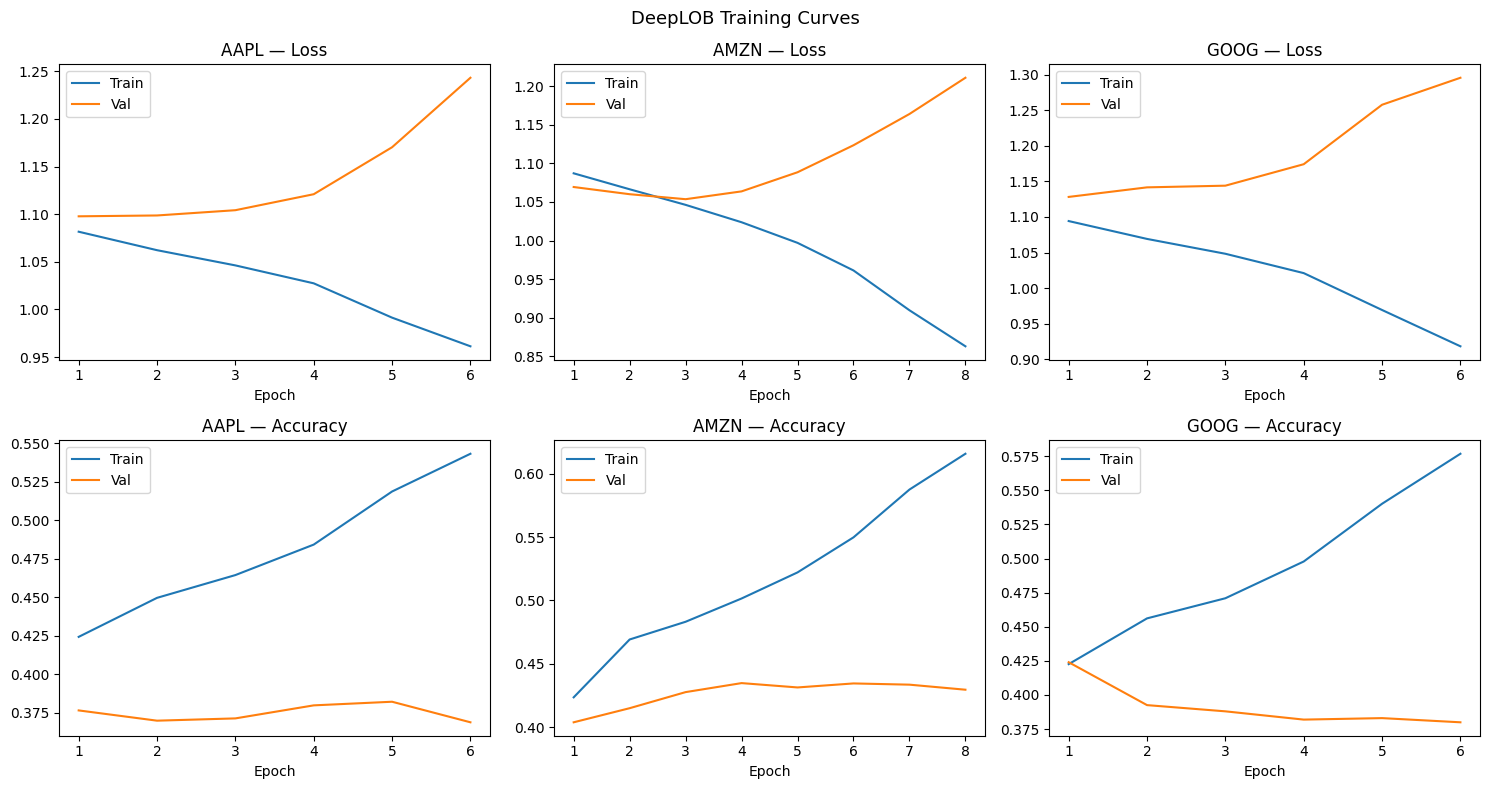

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col, ticker in enumerate(TICKERS):
    h      = training_history[ticker]
    epochs = range(1, len(h["train_loss"]) + 1)

    axes[0, col].plot(epochs, h["train_loss"], label="Train", linewidth=1.5)
    axes[0, col].plot(epochs, h["val_loss"],   label="Val",   linewidth=1.5)
    axes[0, col].set_title(f"{ticker} — Loss")
    axes[0, col].set_xlabel("Epoch")
    axes[0, col].legend()

    axes[1, col].plot(epochs, h["train_acc"], label="Train", linewidth=1.5)
    axes[1, col].plot(epochs, h["val_acc"],   label="Val",   linewidth=1.5)
    axes[1, col].set_title(f"{ticker} — Accuracy")
    axes[1, col].set_xlabel("Epoch")
    axes[1, col].legend()

plt.suptitle("DeepLOB Training Curves", fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
print("Test Set Evaluation\n")
test_results = {}

for ticker in TICKERS:
    model   = trained_models[ticker]
    weights = class_weights[ticker].to(device)
    criterion = nn.CrossEntropyLoss(weight=weights)

    _, _, preds, labels = eval_epoch(model, loaders[ticker]["test"],
                                     criterion, device)

    macro_f1 = f1_score(labels, preds, average="macro")
    test_results[ticker] = {"preds": preds, "labels": labels, "macro_f1": macro_f1}

    print(f"{ticker} — macro F1: {macro_f1:.4f}")
    print(classification_report(labels, preds,
          target_names=["Down", "Stationary", "Up"], digits=3))

Test Set Evaluation

AAPL — macro F1: 0.3372
              precision    recall  f1-score   support

        Down      0.405     0.601     0.484     15370
  Stationary      0.285     0.287     0.286     10886
          Up      0.391     0.176     0.242     13679

    accuracy                          0.370     39935
   macro avg      0.360     0.354     0.337     39935
weighted avg      0.367     0.370     0.347     39935

AMZN — macro F1: 0.3997
              precision    recall  f1-score   support

        Down      0.501     0.547     0.523     11154
  Stationary      0.208     0.348     0.260      4844
          Up      0.551     0.334     0.415     10872

    accuracy                          0.425     26870
   macro avg      0.420     0.410     0.400     26870
weighted avg      0.468     0.425     0.432     26870

GOOG — macro F1: 0.3161
              precision    recall  f1-score   support

        Down      0.519     0.186     0.274      6151
  Stationary      0.205     0.040   

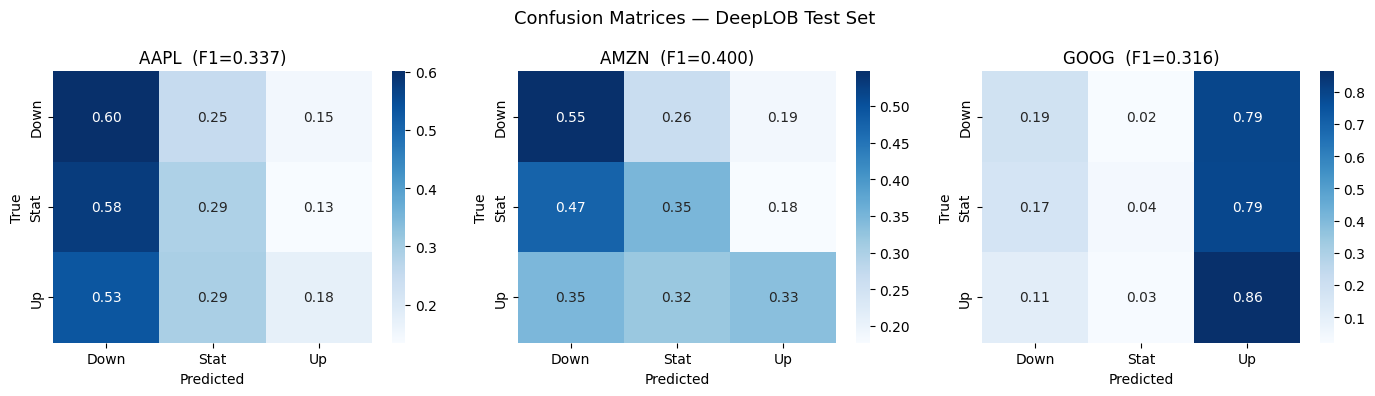

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, ticker in zip(axes, TICKERS):
    cm = confusion_matrix(test_results[ticker]["labels"],
                          test_results[ticker]["preds"], normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", ax=ax,
                xticklabels=["Down", "Stat", "Up"],
                yticklabels=["Down", "Stat", "Up"])
    ax.set_title(f"{ticker}  (F1={test_results[ticker]['macro_f1']:.3f})")
    ax.set_ylabel("True")
    ax.set_xlabel("Predicted")

plt.suptitle("Confusion Matrices — DeepLOB Test Set", fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
print("DeepLOB vs Logistic Regression — Macro F1\n")
print(f"{'Ticker':<8} {'LogReg':>10} {'DeepLOB':>10} {'Delta':>10}")
print("-" * 40)
for ticker in TICKERS:
    lr_f1  = lr_results[ticker]
    dl_f1  = test_results[ticker]["macro_f1"]
    delta  = dl_f1 - lr_f1
    marker = "✓" if delta > 0 else "✗"
    print(f"{ticker:<8} {lr_f1:>10.4f} {dl_f1:>10.4f} {delta:>+10.4f}  {marker}")

DeepLOB vs Logistic Regression — Macro F1

Ticker       LogReg    DeepLOB      Delta
----------------------------------------
AAPL         0.2685     0.3372    +0.0688  ✓
AMZN         0.3850     0.3997    +0.0146  ✓
GOOG         0.4275     0.3161    -0.1114  ✗
